In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [4]:
df = pd.read_csv("NFLX.csv")

df.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,2018-02-05,262.000000,267.899994,250.029999,254.259995,254.259995,11896100
1,2018-02-06,247.699997,266.700012,245.000000,265.720001,265.720001,12595800
2,2018-02-07,266.579987,272.450012,264.329987,264.559998,264.559998,8981500
3,2018-02-08,267.079987,267.619995,250.000000,250.100006,250.100006,9306700
4,2018-02-09,253.850006,255.800003,236.110001,249.470001,249.470001,16906900


In [5]:
df.info()

df.describe()

df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1009 entries, 0 to 1008
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       1009 non-null   object 
 1   Open       1009 non-null   float64
 2   High       1009 non-null   float64
 3   Low        1009 non-null   float64
 4   Close      1009 non-null   float64
 5   Adj Close  1009 non-null   float64
 6   Volume     1009 non-null   int64  
dtypes: float64(5), int64(1), object(1)
memory usage: 55.3+ KB


Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64

In [6]:
df['Date'] = pd.to_datetime(df['Date'])

df.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,2018-02-05,262.000000,267.899994,250.029999,254.259995,254.259995,11896100
1,2018-02-06,247.699997,266.700012,245.000000,265.720001,265.720001,12595800
2,2018-02-07,266.579987,272.450012,264.329987,264.559998,264.559998,8981500
3,2018-02-08,267.079987,267.619995,250.000000,250.100006,250.100006,9306700
4,2018-02-09,253.850006,255.800003,236.110001,249.470001,249.470001,16906900


In [7]:
df['Date'] = df['Date'].map(pd.Timestamp.toordinal)

In [8]:
X = df[['Date','Open','High','Low','Volume']]
y = df['Close']

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [12]:
model = LinearRegression()

model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [13]:
y_pred = model.predict(X_test)

In [14]:
print("MAE :", mean_absolute_error(y_test, y_pred))
print("MSE :", mean_squared_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R² Score:", r2_score(y_test, y_pred))

MAE : 2.8682142224219604
MSE : 16.244655249192675
RMSE: 4.030465884881384
R² Score: 0.998606811885231


In [15]:
results = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})

results.head(10)

,Actual,Predicted
628,509.640015,508.397998
631,494.730011,492.483757
741,500.859985,506.944955
514,380.070007,381.057858
365,315.100006,319.475725
656,476.260010,480.208978
657,495.989990,493.164747
530,298.839996,320.097770
321,359.309998,360.782029
70,328.190002,327.754461


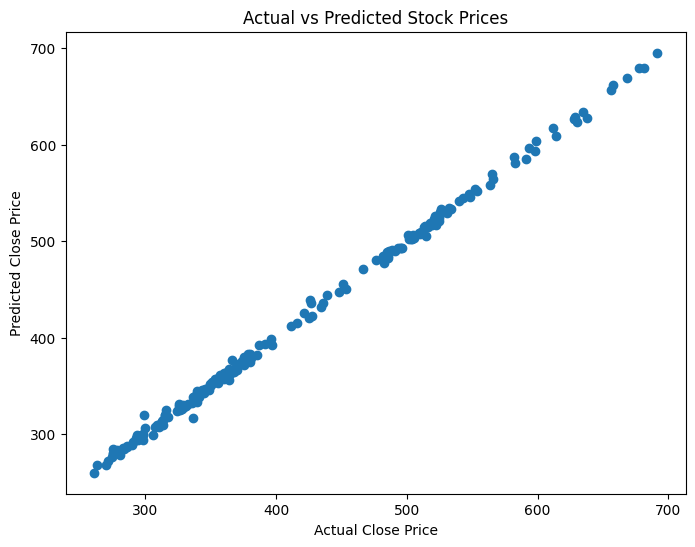

In [16]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Close Price")
plt.ylabel("Predicted Close Price")
plt.title("Actual vs Predicted Stock Prices")

plt.show()

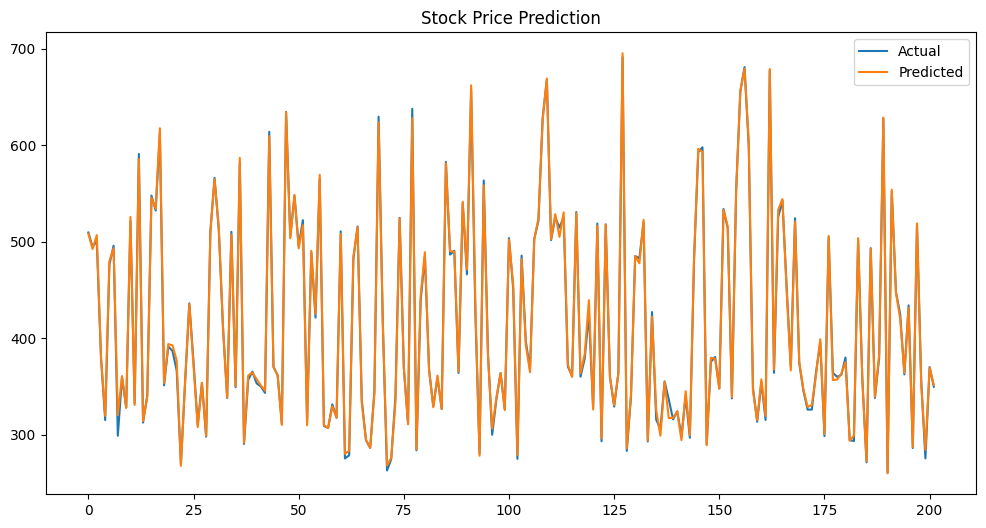

In [17]:
plt.figure(figsize=(12,6))

plt.plot(y_test.values, label='Actual')
plt.plot(y_pred, label='Predicted')

plt.legend()

plt.title("Stock Price Prediction")

plt.show()

In [18]:
new_data = pd.DataFrame({
    'Date':[pd.Timestamp('2024-01-01').toordinal()],
    'Open':[500],
    'High':[510],
    'Low':[495],
    'Volume':[4500000]
})

prediction = model.predict(new_data)

print("Predicted Close Price:", prediction[0])

Predicted Close Price: 505.5477267318622


In [19]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

In [20]:
lr = LinearRegression()
dt = DecisionTreeRegressor(random_state=42)
rf = RandomForestRegressor(random_state=42)

lr.fit(X_train,y_train)
dt.fit(X_train,y_train)
rf.fit(X_train,y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [21]:
models = {
    "Linear Regression": lr,
    "Decision Tree": dt,
    "Random Forest": rf
}

for name, model in models.items():
    pred = model.predict(X_test)
    print(name)
    print("R²:", r2_score(y_test,pred))
    print("RMSE:", np.sqrt(mean_squared_error(y_test,pred)))
    print()

Linear Regression
R²: 0.998606811885231
RMSE: 4.030465884881384

Decision Tree
R²: 0.9959139415267152
RMSE: 6.902440278571893

Random Forest
R²: 0.9975098208401577
RMSE: 5.388472442924366



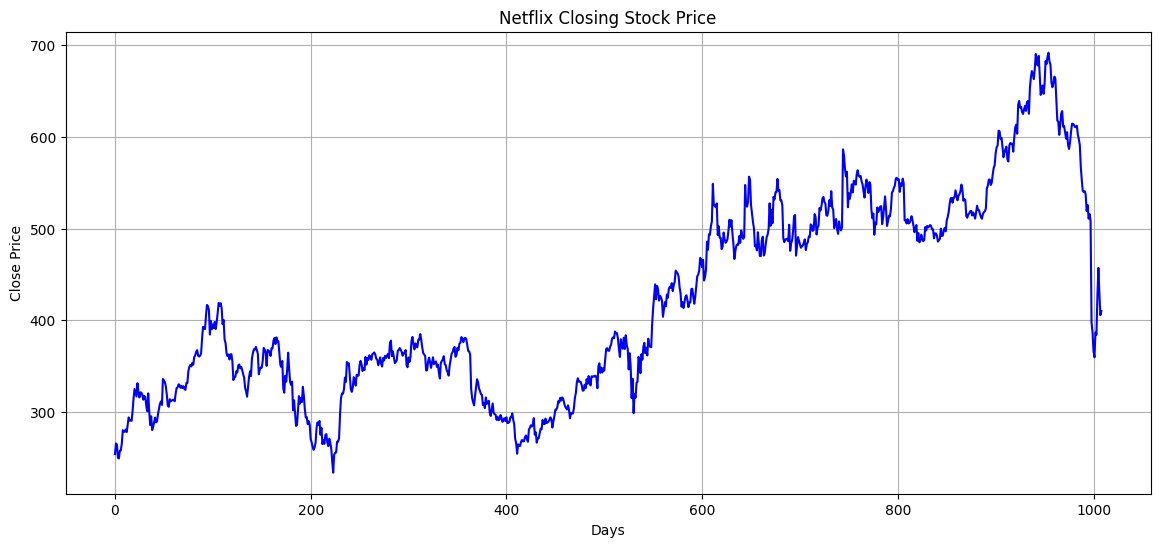

In [22]:
plt.figure(figsize=(14,6))

plt.plot(df['Close'], color='blue')

plt.title("Netflix Closing Stock Price")
plt.xlabel("Days")
plt.ylabel("Close Price")

plt.grid(True)

plt.show()

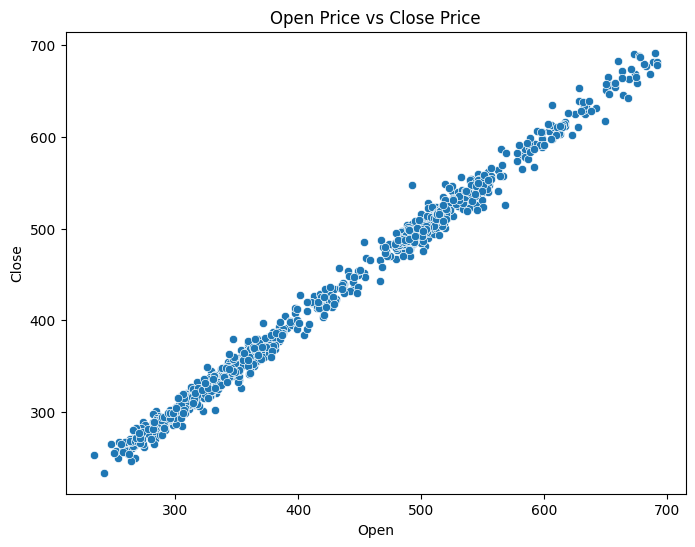

In [23]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x='Open',
    y='Close'
)

plt.title("Open Price vs Close Price")

plt.show()

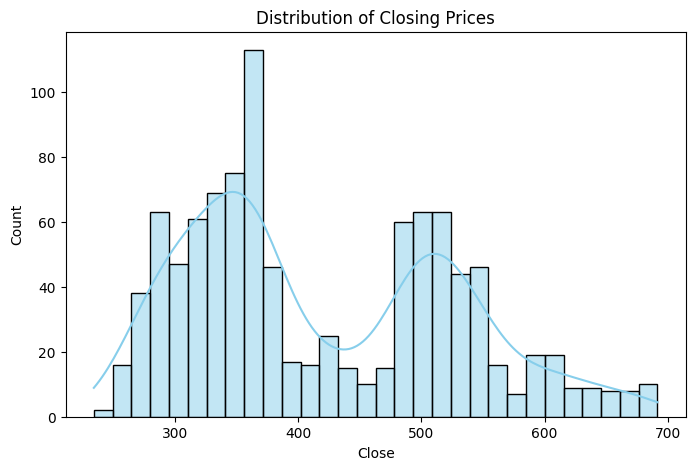

In [24]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['Close'],
    bins=30,
    kde=True,
    color='skyblue'
)

plt.title("Distribution of Closing Prices")

plt.show()

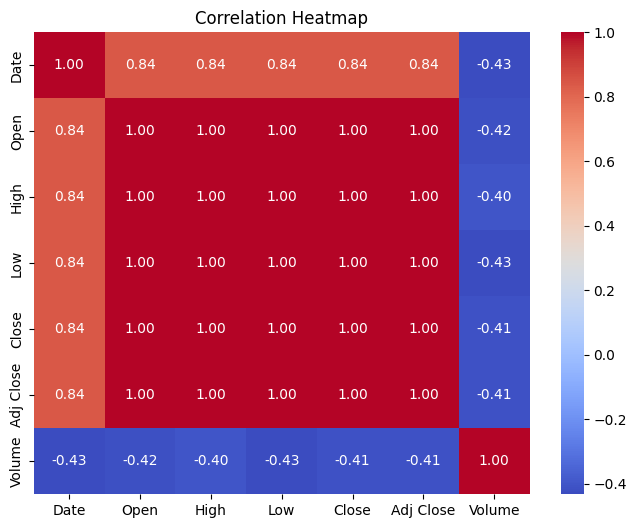

In [25]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm',
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

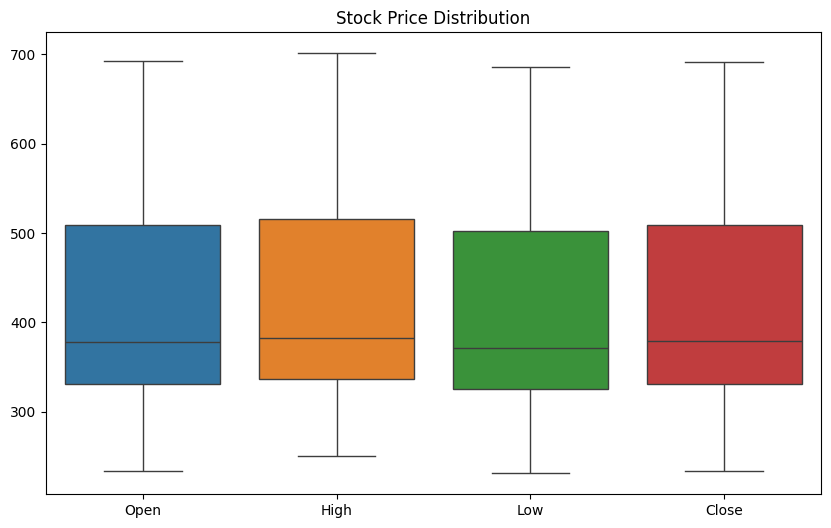

In [26]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=df[['Open','High','Low','Close']]
)

plt.title("Stock Price Distribution")

plt.show()

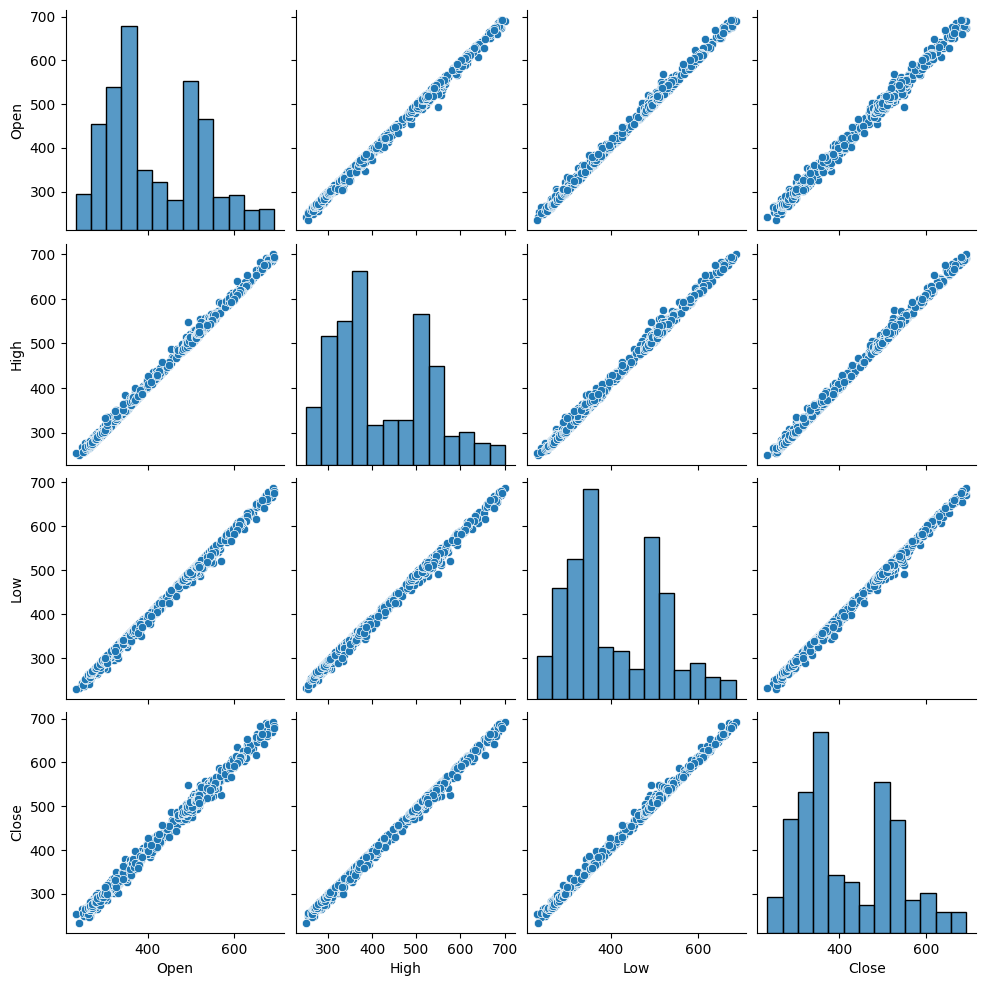

In [27]:
sns.pairplot(
    df[['Open','High','Low','Close']]
)

plt.show()

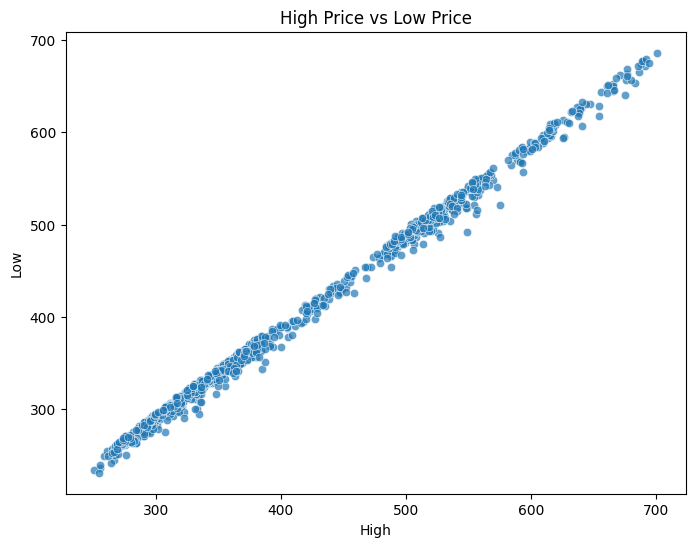

In [28]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x='High',
    y='Low',
    alpha=0.7
)

plt.title("High Price vs Low Price")

plt.show()

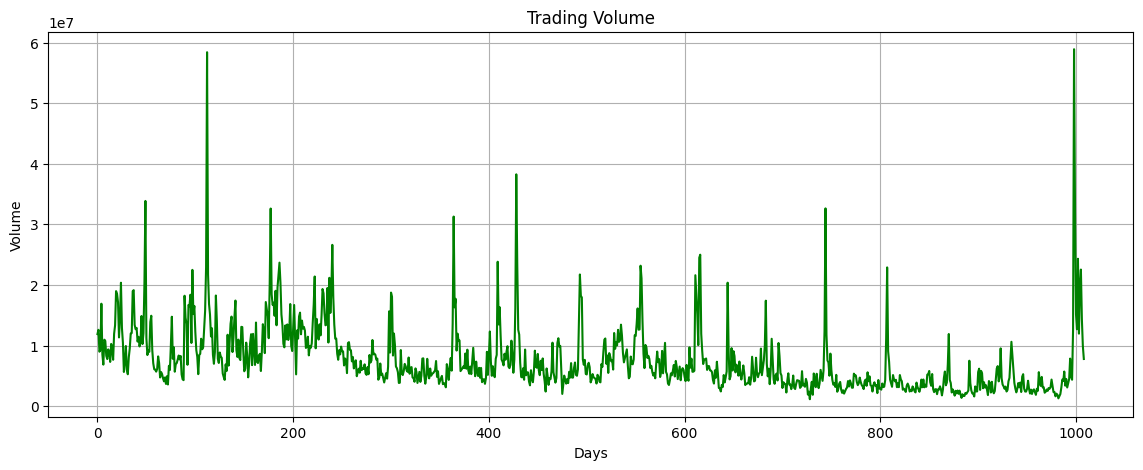

In [29]:
plt.figure(figsize=(14,5))

plt.plot(df['Volume'], color='green')

plt.title("Trading Volume")
plt.xlabel("Days")
plt.ylabel("Volume")

plt.grid(True)

plt.show()

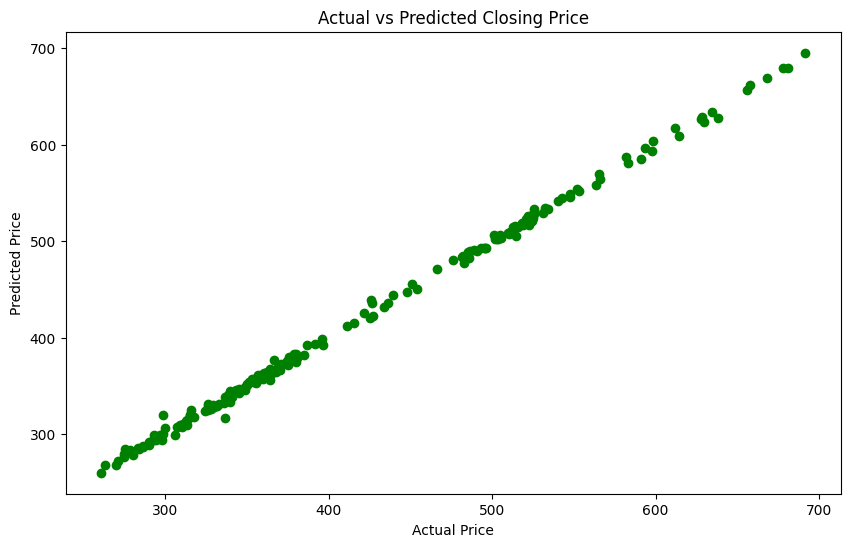

In [31]:
plt.figure(figsize=(10,6))

plt.scatter(
    y_test,
    y_pred,
    color='green'
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Closing Price")

plt.show()

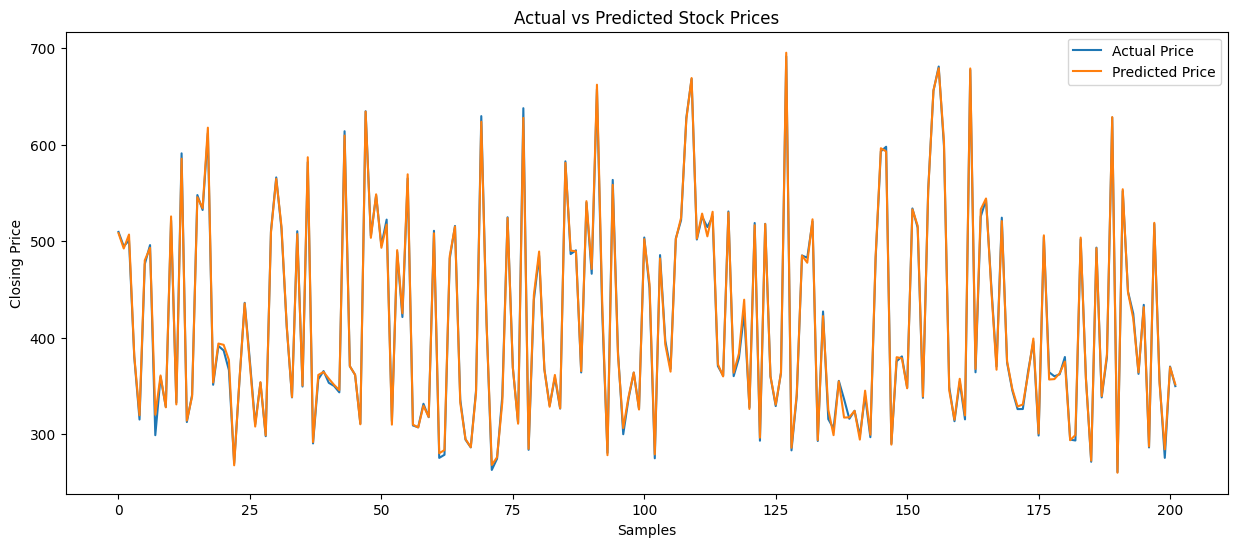

In [32]:
plt.figure(figsize=(15,6))

plt.plot(y_test.values, label='Actual Price')

plt.plot(y_pred, label='Predicted Price')

plt.title("Actual vs Predicted Stock Prices")

plt.xlabel("Samples")
plt.ylabel("Closing Price")

plt.legend()

plt.show()

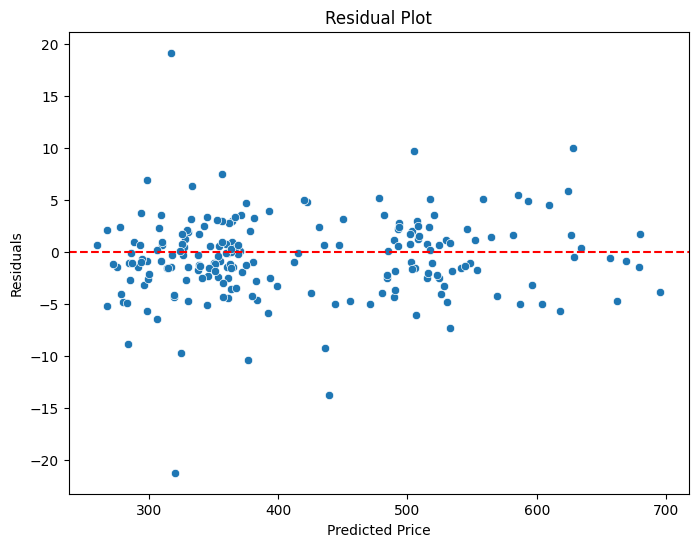

In [33]:
residuals = y_test - y_pred

plt.figure(figsize=(8,6))

sns.scatterplot(
    x=y_pred,
    y=residuals
)

plt.axhline(
    y=0,
    color='red',
    linestyle='--'
)

plt.xlabel("Predicted Price")
plt.ylabel("Residuals")

plt.title("Residual Plot")

plt.show()

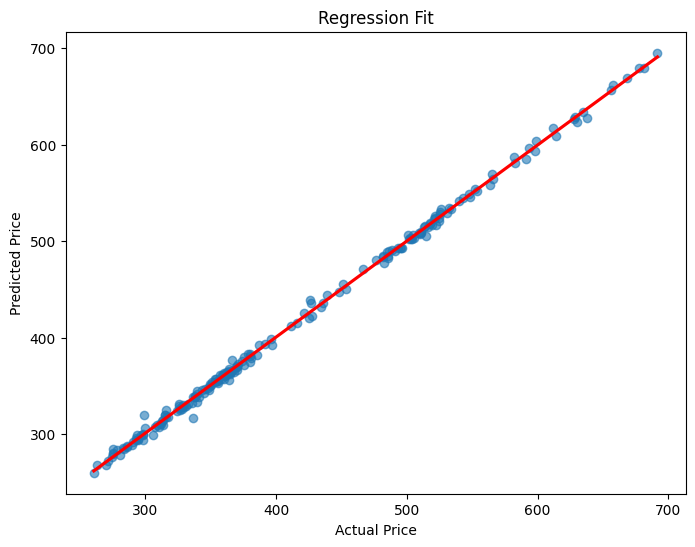

In [34]:
plt.figure(figsize=(8,6))

sns.regplot(
    x=y_test,
    y=y_pred,
    scatter_kws={'alpha':0.6},
    line_kws={'color':'red'}
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")

plt.title("Regression Fit")

plt.show()